# ov.synbio II — circuits, CRISPR, assembly & pathway design

The [first tutorial](t_synbio_01_intro.ipynb) covered the metabolism ↔ protein ↔ DNA core. This one tours the rest of the **design-build-test-learn** cycle that `ov.synbio` now supports — the parts of synthetic biology a metabolic/protein toolkit alone doesn't reach:

- **Genetic circuits & regulation** — build gene circuits and simulate them (ODE + stochastic), predict RBS / promoter strength, fold RNA
- **CRISPR & genome editing** — design and score guide RNAs, base-editing windows, HDR donors
- **DNA assembly** — Golden Gate / Gibson construction, restriction maps, GenBank annotation
- **Pathway design** — reaction thermodynamics (MDF), retrosynthesis over a genome-scale model
- **Library design** — degenerate codons, saturation & DMS libraries

Everything here is **CPU-only** (COBRApy, scipy, ViennaRNA, Biopython, optlang). `pip install 'omicverse[synbio]'`.

In [1]:
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


## 1 — Genetic circuits

`genetic_circuit` builds a gene-regulatory network from a template (or from parts). `simulate_circuit` integrates it — deterministically (ODEs, Hill kinetics) or stochastically (Gillespie SSA). Start with the **Gardner toggle switch**: two mutually repressing genes give a *bistable* system that latches into one state.

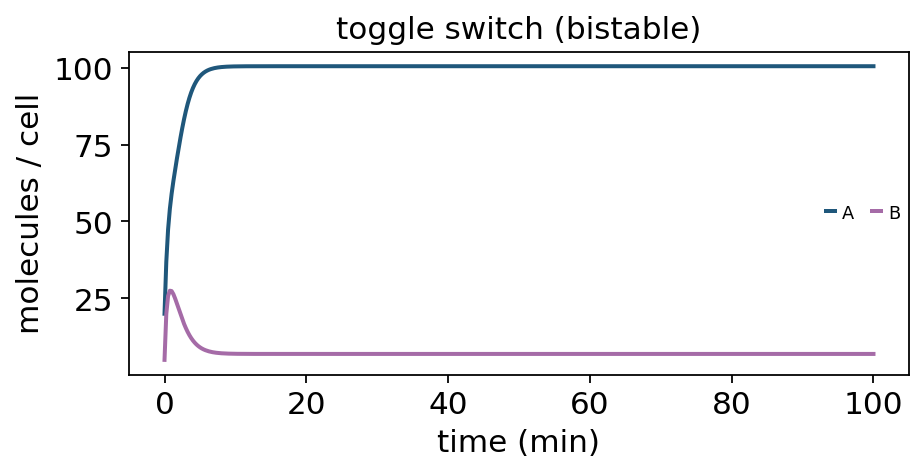

In [2]:
toggle = ov.synbio.genetic_circuit('toggle_switch')
df = ov.synbio.simulate_circuit(toggle, t_end=100, method='ode')
ov.synbio.plot_circuit(df, title='toggle switch (bistable)')
None

The **Elowitz repressilator** — three repressors in a ring (A ⊣ B ⊣ C ⊣ A) — has an unstable fixed point and *oscillates*. This is the canonical synthetic oscillator.

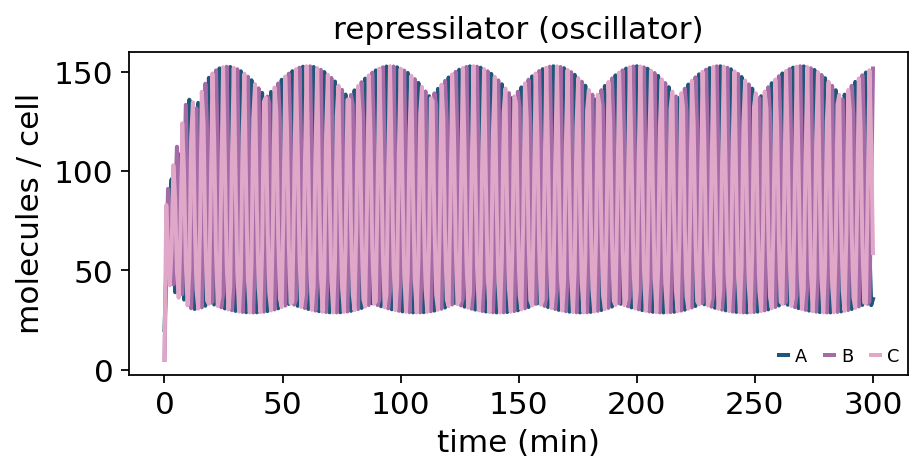

In [3]:
rep = ov.synbio.genetic_circuit('repressilator')
ov.synbio.plot_circuit(ov.synbio.simulate_circuit(rep, t_end=300), title='repressilator (oscillator)')
None

Stochastic simulation captures the molecular noise that makes small circuits behave probabilistically — the same toggle, run as a Gillespie SSA:

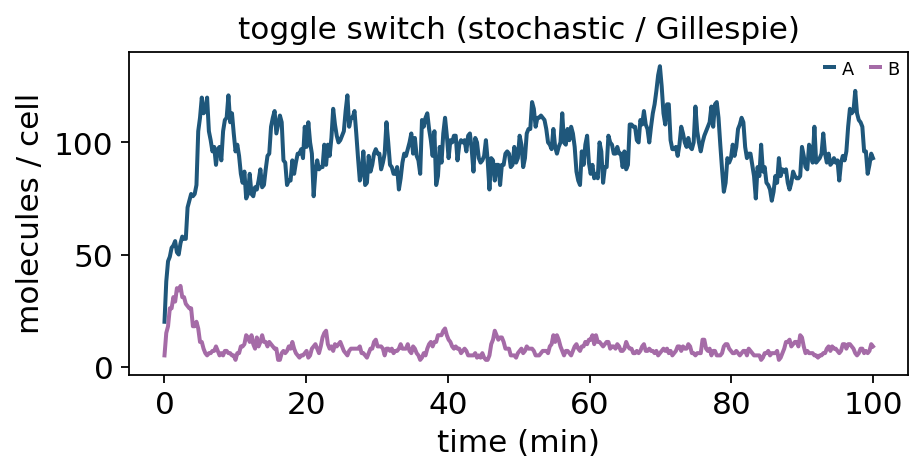

In [4]:
ov.synbio.plot_circuit(ov.synbio.simulate_circuit(toggle, t_end=100, method='stochastic'),
                       title='toggle switch (stochastic / Gillespie)')
None

### 1.1 — Regulatory-element strength

Before a circuit works you must tune its parts. `rbs_strength` predicts a translation-initiation rate from a 5'UTR (Shine–Dalgarno : anti-SD hybridisation minus the mRNA-unfolding cost, via ViennaRNA); `promoter_strength` scores a σ70 promoter's −10/−35 boxes.

In [5]:
strong = ov.synbio.rbs_strength('AAAGAGGAGAAATACTAGATGAAACGT')   # consensus SD
weak   = ov.synbio.rbs_strength('AAACTCTCTAAATACTAGATGAAACGT')   # no SD
print('strong RBS rate:', round(strong.initiation_rate, 1))
print('weak   RBS rate:', round(weak.initiation_rate, 1))
ov.synbio.promoter_strength('AACGATTTGACATGCTAGCTATAATGGCACG')

strong RBS rate: 6003.9
weak   RBS rate: 20.7


{'strength': 0.3333333333333333,
 'minus35': 'ACGATT',
 'minus10': 'TGGCAC',
 'spacer': 17,
 'score35': 0.3333333333333333,
 'score10': 0.3333333333333333}

**Compare algorithms.** The RBS strength above uses `method='thermodynamic'` (a transparent SD:anti-SD baseline). `method='ostir'` runs **OSTIR**, the open-source reimplementation of the Salis **RBS Calculator v2** — a real, published translation-initiation-rate predictor. Both agree that the strong-SD construct is far stronger; OSTIR reports calibrated TIR units.

In [6]:
strong='AAAGAGGAGAAATACTAGATGAAACGTATTGCACGT'; weakrbs='AAACTCTCTAAATACTAGATGAAACGTATTGCACGT'
for nm,s in [('strong SD',strong),('weak SD',weakrbs)]:
    b=ov.synbio.rbs_strength(s, method='thermodynamic').initiation_rate
    o=ov.synbio.rbs_strength(s, method='ostir').initiation_rate
    print(f'{nm:10s}  thermodynamic={b:9.0f}   OSTIR(RBS Calculator)={o:9.0f}')

strong SD   thermodynamic=     3828   OSTIR(RBS Calculator)=   107603
weak SD     thermodynamic=       21   OSTIR(RBS Calculator)=      981


## 2 — CRISPR guide design

`design_grnas` scans both strands for PAM sites (SpCas9 `NGG` here), extracts protospacers, and ranks them by an efficiency heuristic. `offtarget_search` then scores near-matches with a seed-weighted (CFD-style) model.

In [7]:
locus = 'ATGGCACGTGGATCCGGACATGCACCGGTTAACGGGACCGGTTAACCGGTACCGGTTGCACCATGAAA' * 2
guides = ov.synbio.design_grnas(locus, enzyme='SpCas9')
print(f'{len(guides)} guides; best:', guides[0])
offs = ov.synbio.offtarget_search(guides[0].spacer, locus)
print('off-target hits:', len(offs), '| top CFD:', round(offs[0].cfd, 3))

23 guides; best: Guide(TGCACCATGAAAATGGCACG TGG +@56 GC=0.50 eff=1.00)
off-target hits: 1 | top CFD: 1.0


`plot_grna_efficiency` maps the candidate guides along the target — position vs on-target efficiency, coloured by strand, sized by GC — so you can see where the good guides cluster.

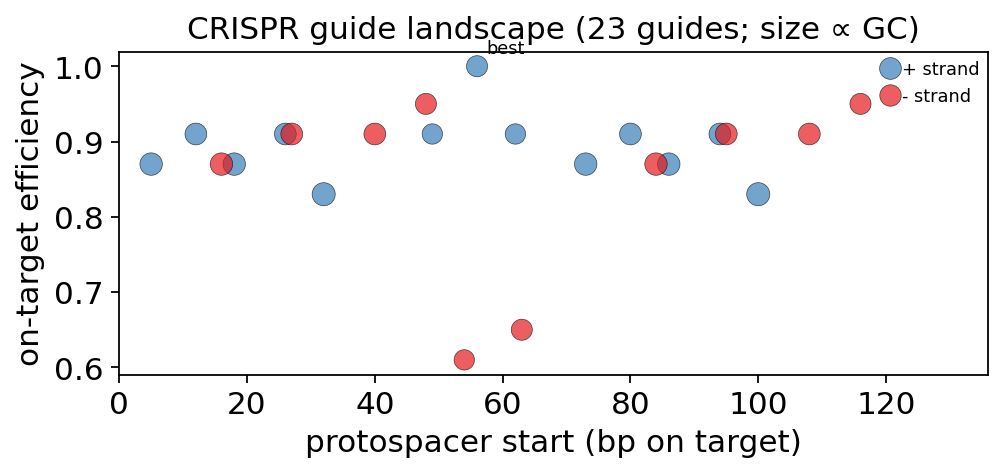

In [8]:
ov.synbio.plot_grna_efficiency(guides, target_len=len(locus))
None

Plan an edit: a base-editor window (ABE, A→G) and HDR homology arms for a knock-in donor.

In [9]:
print(ov.synbio.base_editor_window(guides[0].spacer, editor='ABE'))
donor = ov.synbio.hdr_arms(locus, cut_site=40, arm_length=20, insert='ATGTAG')
print('HDR donor:', donor['left_len'], '+ insert +', donor['right_len'], 'bp')

{'editor': 'ABE', 'window': (4, 8), 'target_base': 'A', 'n_edits': 2, 'edits': [{'position': 4, 'from': 'A', 'to': 'G'}, {'position': 7, 'from': 'A', 'to': 'G'}], 'edited_spacer': 'TGCGCCGTGAAAATGGCACG'}
HDR donor: 20 + insert + 20 bp


## 3 — DNA assembly

`golden_gate` simulates Type IIS (BsaI) assembly: it reads each fragment's 4-nt fusion overhangs and orders them into a circular construct. `restriction_map` and `annotate_construct` help you read the result.

In [10]:
def frag(left, insert, right):
    return 'TTGGTCTCA' + left + insert + right + 'AGAGACCTT'   # BsaI site .. overhang

res = ov.synbio.golden_gate([frag('AATG', 'CCCCCCCC', 'GTTA'),
                             frag('GTTA', 'GGGGGGGG', 'AATG')], enzyme='BsaI')
print(res, '| junction overhangs:', res.junctions)
ov.synbio.restriction_map('GAATTCGGATCCAAGCTTGGTACC', enzymes=['EcoRI', 'BamHI', 'HindIII'])

AssemblyResult(GoldenGate/BsaI, 2 fragments -> 24 bp, circular=True) | junction overhangs: ['AATG', 'GTTA']


{'EcoRI': [2], 'BamHI': [8], 'HindIII': [14]}

## 4 — Pathway design: thermodynamics & retrosynthesis

A designed pathway must be thermodynamically feasible. `max_min_driving_force` (MDF) optimises metabolite concentrations to maximise the driving force of the *weakest* step — a positive MDF means the route can run; the limiting reaction is the bottleneck.

In [11]:
reactions = {'pgi': {'g6p': -1, 'f6p': 1},
             'pfk': {'f6p': -1, 'atp': -1, 'fdp': 1, 'adp': 1, 'h': 1}}
dg0 = {r: ov.synbio.reaction_dg(s) for r, s in reactions.items()}
mdf = ov.synbio.max_min_driving_force(reactions, dg0, fixed={'h': 1e-7, 'h2o': 1})
print('MDF =', round(mdf.mdf, 2), 'kJ/mol | feasible:', mdf.feasible,
      '| bottleneck:', mdf.bottleneck)

MDF = 20.65 kJ/mol | feasible: True | bottleneck: pgi


**Compare algorithms.** The MDF above used `reaction_dg(method='baseline')` (a small built-in ΔGf table). `method='equilibrator'` runs the **real eQuilibrator** component-contribution method (Noor 2013; Beber 2022) — the field-standard reaction-thermodynamics tool (first use downloads a ~2 GB cache).

  pgi   baseline=     3.10   eQuilibrator(real)=     2.64  kJ/mol


  pfk   baseline=    32.90   eQuilibrator(real)=   -17.81  kJ/mol


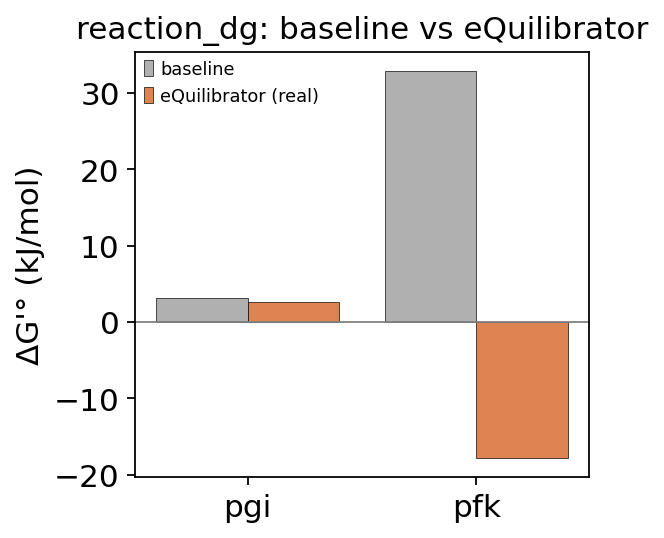

In [12]:
# reaction ΔG'°: built-in baseline table vs REAL eQuilibrator — side by side
labels, base, equi = [], [], []
for r, s in reactions.items():
    b = ov.synbio.reaction_dg(s, method='baseline')
    e = ov.synbio.reaction_dg(s, method='equilibrator')   # component-contribution (Noor 2013)
    print(f"  {r:4s}  baseline={b:9.2f}   eQuilibrator(real)={e:9.2f}  kJ/mol")
    labels.append(r); base.append(b); equi.append(e)
ov.synbio.plot_method_comparison(labels, {'baseline': base, 'eQuilibrator (real)': equi},
    ylabel="ΔG'° (kJ/mol)", title='reaction_dg: baseline vs eQuilibrator')
None

`plot_driving_forces` shows why: the driving force of every step, with the MDF as a line and the **bottleneck** reaction in red — the one to engineer (a better enzyme, or shifted concentrations) if the pathway stalls.

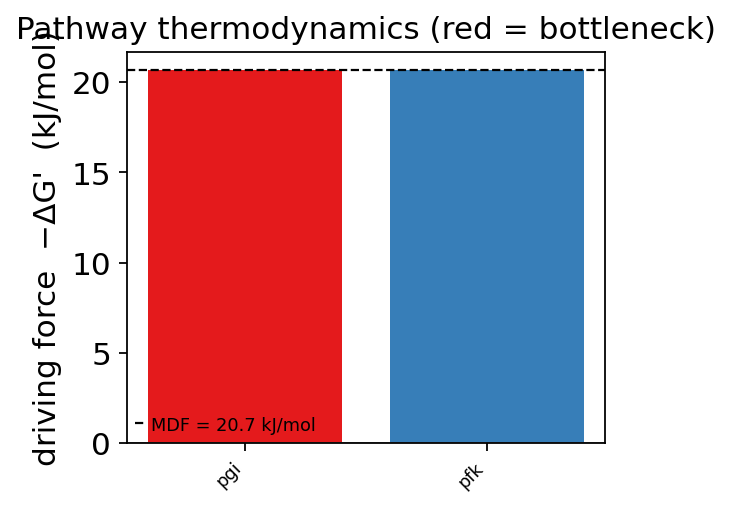

In [13]:
ov.synbio.plot_driving_forces(mdf)
None

`pathway_search` does retrosynthesis *within* a genome-scale model — the shortest routes that produce a target metabolite (which enzymes to express).

In [14]:
m = ov.synbio.load_gem('e_coli_core')
paths = ov.synbio.pathway_search(m, 'succ_c', max_depth=5, max_paths=3)
for p in paths:
    print(f'{p.length} steps:', p.reactions)

INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the Cobrapy repository.


INFO:cobra.io.web.load:Attempting to fetch 'e_coli_core' from the BiGG Models repository.


Output()

INFO:httpx:HTTP Request: GET http://bigg.ucsd.edu/static/models/e_coli_core.xml.gz "HTTP/1.1 200 OK"


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


1 steps: ['SUCCt2_2']
2 steps: ['FRD7', 'FUMt2_2']
3 steps: ['SUCOAS', 'AKGDH', 'AKGt2r']


## 5 — Library design

To *test* variants you design libraries. `degenerate_codon` finds the minimal IUPAC codon covering a target amino-acid set (all 20 → NNK/NNS), and `saturation_library` / `dms_library` size the screen.

In [15]:
print('all 20 AA  ->', ov.synbio.degenerate_codon(list('ACDEFGHIKLMNPQRSTVWY')))
print('aromatics  ->', ov.synbio.degenerate_codon(['F', 'Y', 'W']))
print('NNK x3 site-saturation:', ov.synbio.saturation_library(3, 'NNK'))

all 20 AA  -> DegenerateCodon(NNS: 32 codons -> 20 AA, missing=[])
aromatics  -> DegenerateCodon(TDS: 6 codons -> 5 AA, missing=[])
NNK x3 site-saturation: {'scheme': 'NNK', 'positions': 3, 'codons_per_site': 32, 'aa_per_site': 20, 'stop_fraction_per_site': 0.031, 'dna_diversity': 32768, 'protein_diversity': 8000, 'screen_for_95pct': 98304}


## Summary

Together with the [core tutorial](t_synbio_01_intro.ipynb), `ov.synbio` now spans the full **design-build-test-learn** cycle: metabolic modelling, enzyme design, **genetic-circuit design & simulation**, **regulatory-element engineering**, **CRISPR editing**, **DNA assembly**, **pathway thermodynamics & retrosynthesis**, and **library design** — all AnnData-independent, registered under `synthetic_biology`, and gated so `import omicverse` never needs the extra.

For model-guided directed evolution that combines this with the protein layer, see `ov.synbio.ml_guided_design`, which scores single mutations with ESM and greedily builds multi-mutant designs.